In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data")).resolve()

df_per_subject = pd.read_csv(output_dir / "datasets_tidy_per_subject.csv")
df_total = pd.read_csv(output_dir / "datasets_tidy_total.csv")

pivot_per_subject = df_per_subject.pivot_table(index="dataset", columns="dotpath", values="value", aggfunc="first")
pivot_total = df_total.pivot_table(index="dataset", columns="dotpath", values="value", aggfunc="first")
datasets_list = df_per_subject["dataset"].unique().tolist()

print(f"Loaded {len(datasets_list)} dataset(s)")

Loaded 19 dataset(s)


In [2]:
import sys
sys.path.insert(0, str(Path(__file__).resolve().parents[1])) if "__file__" in dir() else sys.path.insert(0, "../")
from analysis.visualisation import (
    make_bubble_chart, make_legend, make_legend_per_subject,
    make_neuroimaging_depthvsbreadth, make_task_composition_radar,
    make_radar_grid, compute_dataset_ranks, turbo_color, DATASET_COLORS,
)
from analysis.tables import COLUMN_GROUPS_PER_SUBJECT, COLUMN_GROUPS_TOTAL

In [3]:
# Rank top-10 datasets by total brain-recording hours per subject; build shared color dicts.
dataset_ranks = compute_dataset_ranks(pivot_per_subject, datasets_list, COLUMN_GROUPS_PER_SUBJECT)
dataset_colors_turbo = {ds: turbo_color(rank) for ds, rank in dataset_ranks.items()}

# Ordered list of top-10 (rank 10 first) with their colors — used for radar grid and short chart.
datasets_top10_ranked = sorted(
    [(ds, dataset_colors_turbo[ds]) for ds, rank in dataset_ranks.items() if rank > 0],
    key=lambda x: dataset_ranks[x[0]],
    reverse=True,
)
datasets_top10 = [ds for ds, _ in datasets_top10_ranked]

print("Top-10 datasets (rank 10 → 1):")
for ds, color in datasets_top10_ranked:
    print(f"  rank {dataset_ranks[ds]:2d}  {ds:30s}  {color}")

Top-10 datasets (rank 10 → 1):
  rank 10  CNeuroMod                       (np.float64(0.973416), np.float64(0.585761), np.float64(0.25154), np.float64(1.0))
  rank  9  IBC                             (np.float64(0.973416), np.float64(0.585761), np.float64(0.25154), np.float64(1.0))
  rank  8  NSD                             (np.float64(0.963203), np.float64(0.553865), np.float64(0.271909), np.float64(1.0))
  rank  7  Dr Who                          (np.float64(0.907365), np.float64(0.434524), np.float64(0.35297), np.float64(1.0))
  rank  6  BOLD5000                        (np.float64(0.836801), np.float64(0.329105), np.float64(0.430905), np.float64(1.0))
  rank  5  MyConnectome                    (np.float64(0.752312), np.float64(0.227133), np.float64(0.513149), np.float64(1.0))
  rank  4  MSC                             (np.float64(0.650746), np.float64(0.125309), np.float64(0.595617), np.float64(1.0))
  rank  3  NL-fMRI                         (np.float64(0.523633), np.float64(0.0245

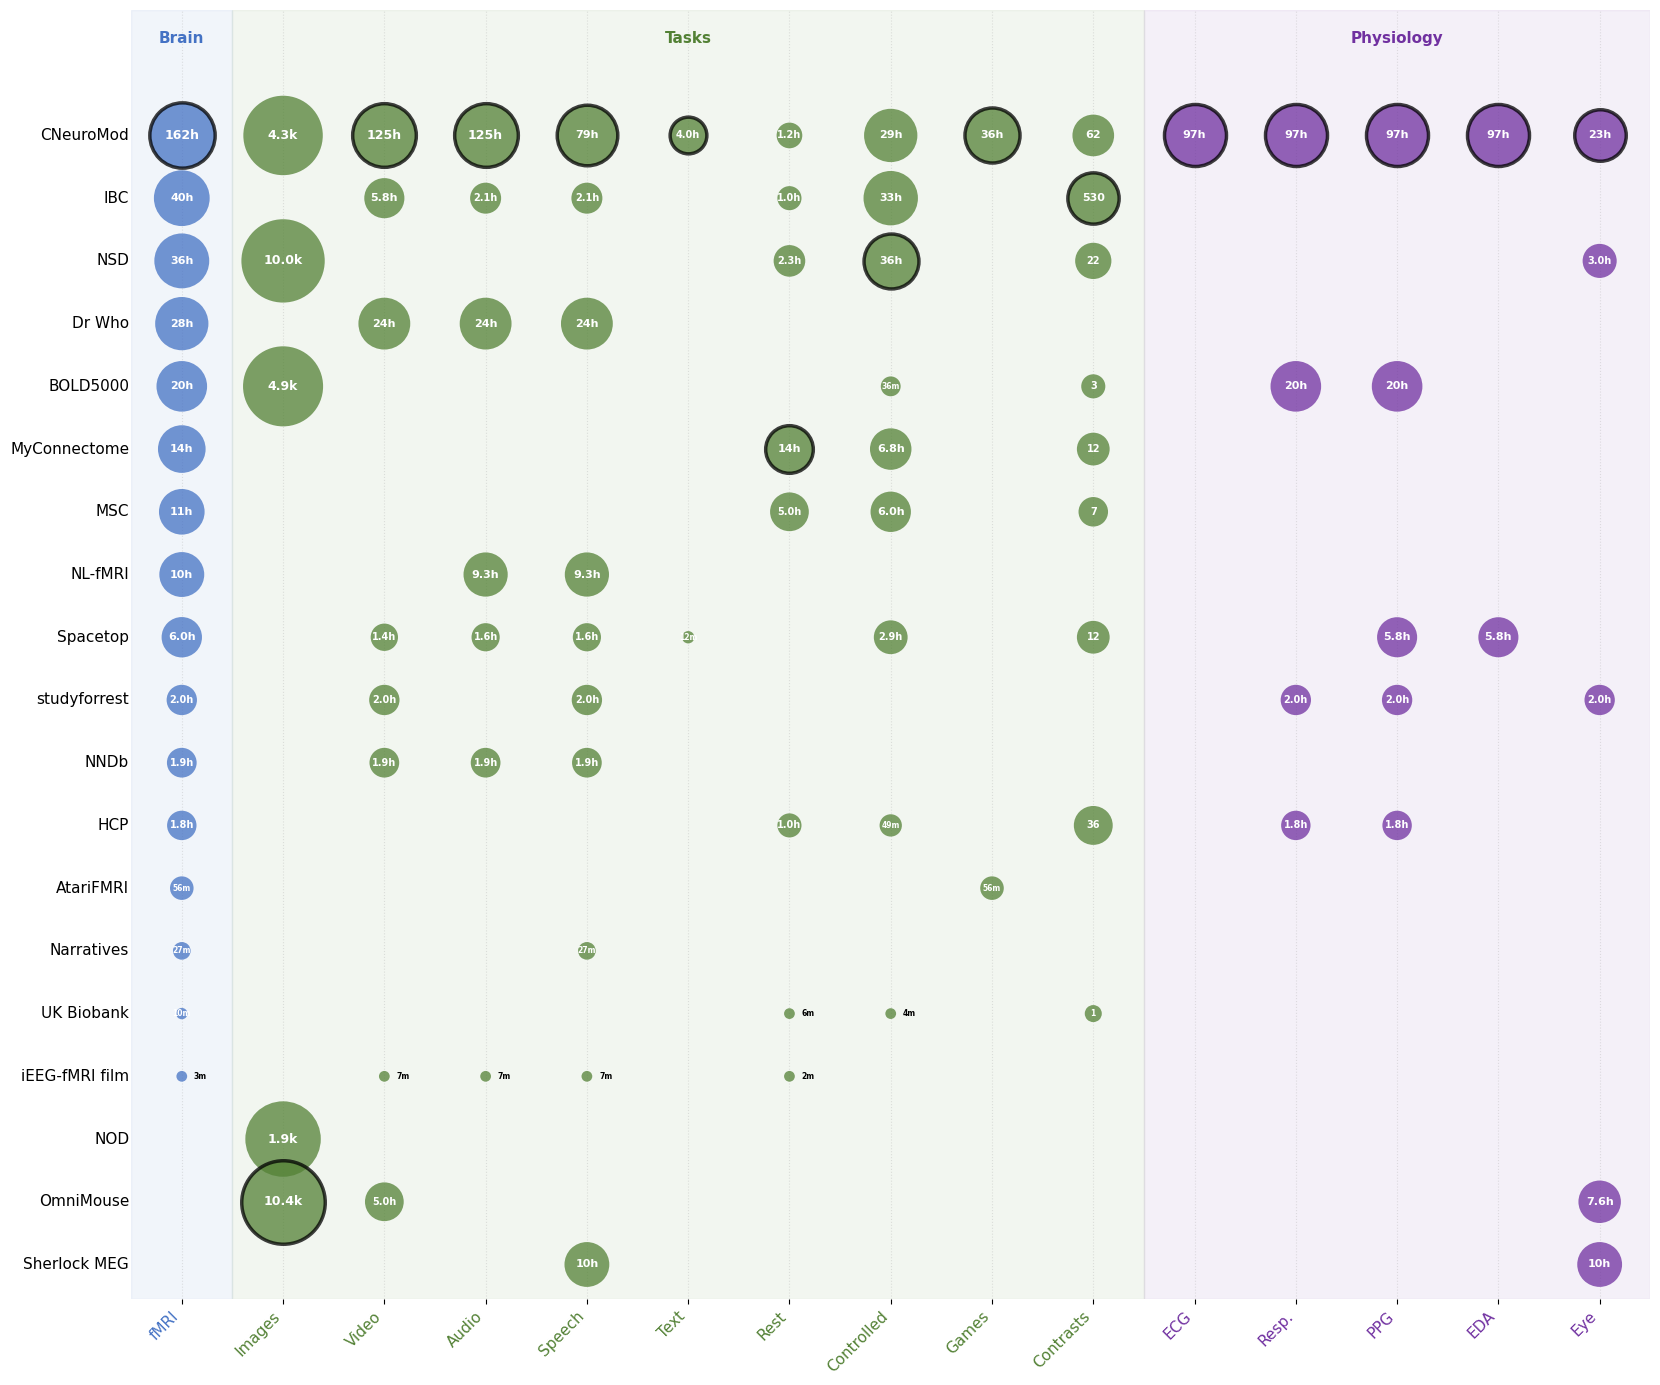

Saved dataset_comparison_per_subject.png


In [4]:
make_bubble_chart(
    COLUMN_GROUPS_PER_SUBJECT,
    pivot_per_subject,
    datasets_list,
    None,
    output_dir / "dataset_comparison_per_subject.png",
)

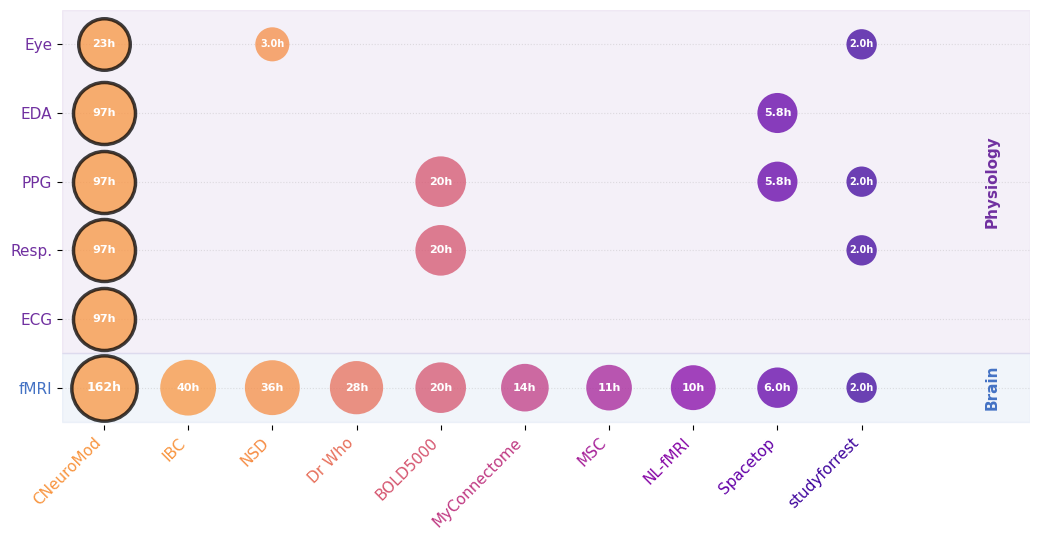

Saved dataset_comparison_per_subject_short.png


In [5]:
make_bubble_chart(
    [g for g in COLUMN_GROUPS_PER_SUBJECT if g[0] != "Tasks"],
    pivot_per_subject,
    datasets_top10,
    None,
    output_dir / "dataset_comparison_per_subject_short.png",
    row_colors=dataset_colors_turbo,
    transpose=True,
)

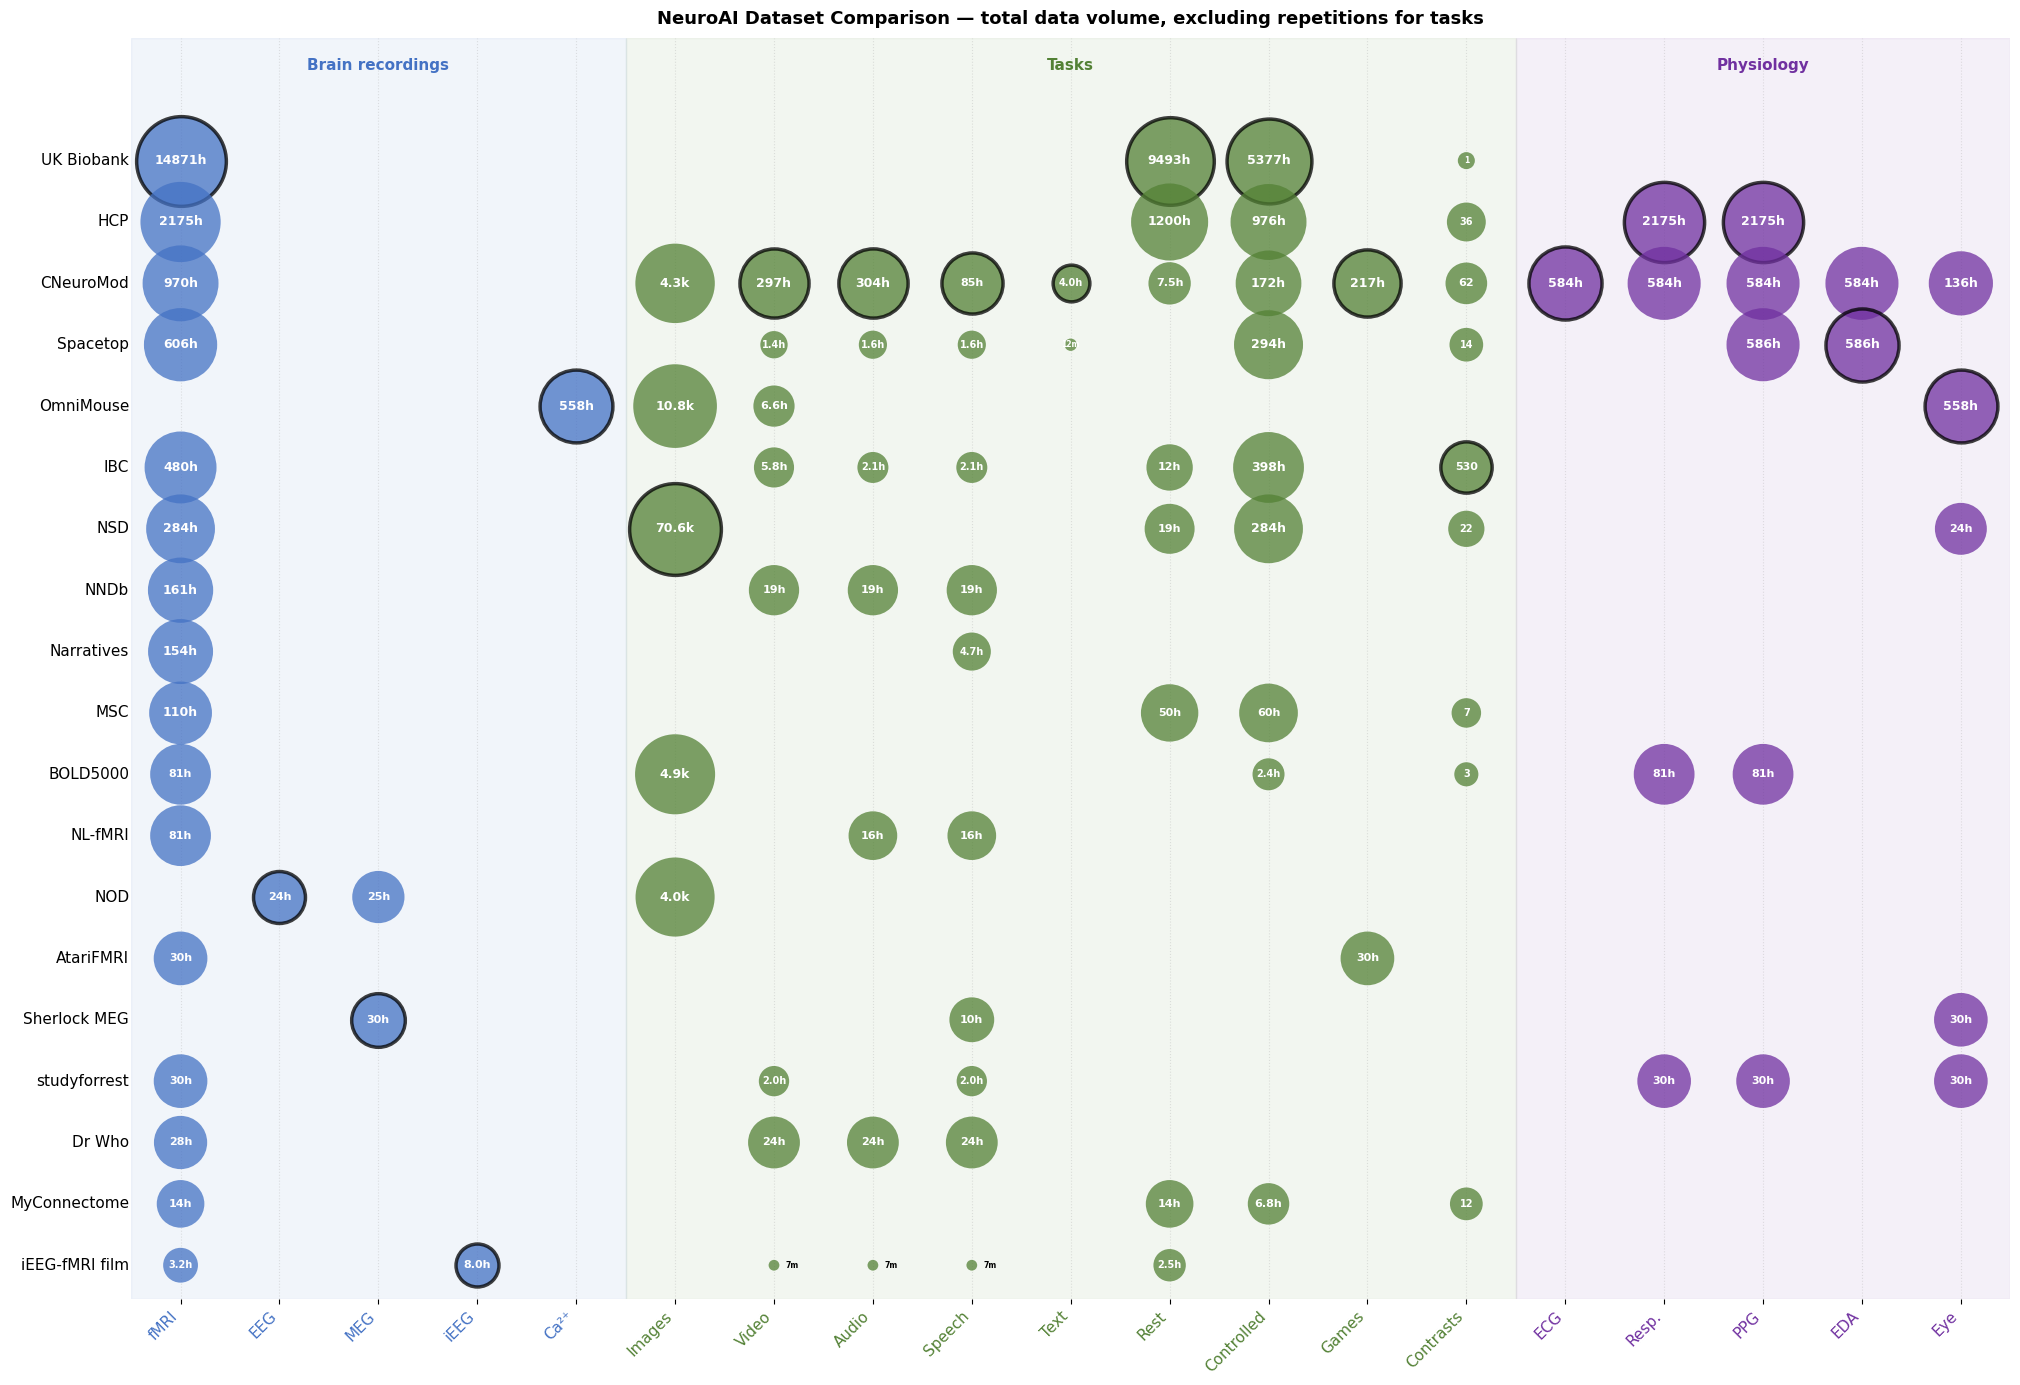

Saved dataset_comparison_total.png


In [6]:
make_bubble_chart(
    COLUMN_GROUPS_TOTAL,
    pivot_total,
    datasets_list,
    "NeuroAI Dataset Comparison — total data volume, excluding repetitions for tasks",
    output_dir / "dataset_comparison_total.png",
)

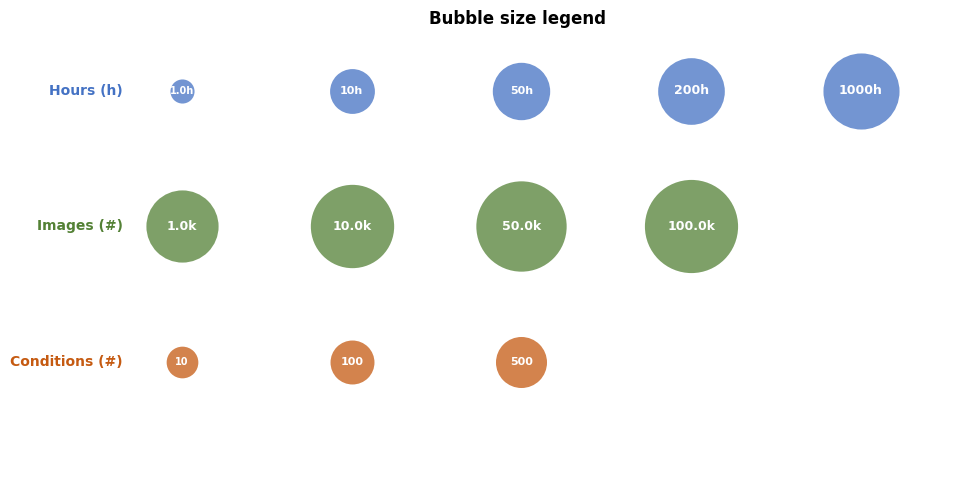

Saved dataset_comparison_legend.png


In [7]:
make_legend(output_dir / "dataset_comparison_legend.png")

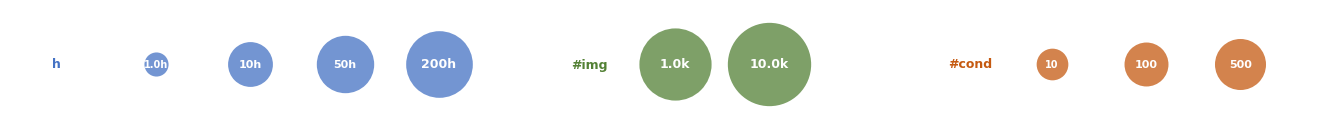

Saved dataset_comparison_legend_per_subject.png


In [8]:
make_legend_per_subject(output_dir / "dataset_comparison_legend_per_subject.png")

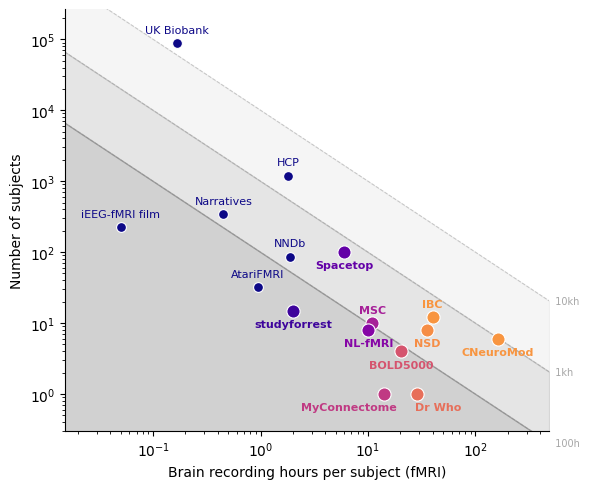

Saved dataset_neuroimaging_depthvsbreadth.png


In [9]:
make_neuroimaging_depthvsbreadth(
    pivot_per_subject,
    pivot_total,
    datasets_list,
    output_dir / "dataset_neuroimaging_depthvsbreadth.png",
    column_groups_per_subject=COLUMN_GROUPS_PER_SUBJECT,
    column_groups_total=COLUMN_GROUPS_TOTAL,
    dataset_colors=dataset_colors_turbo,
)

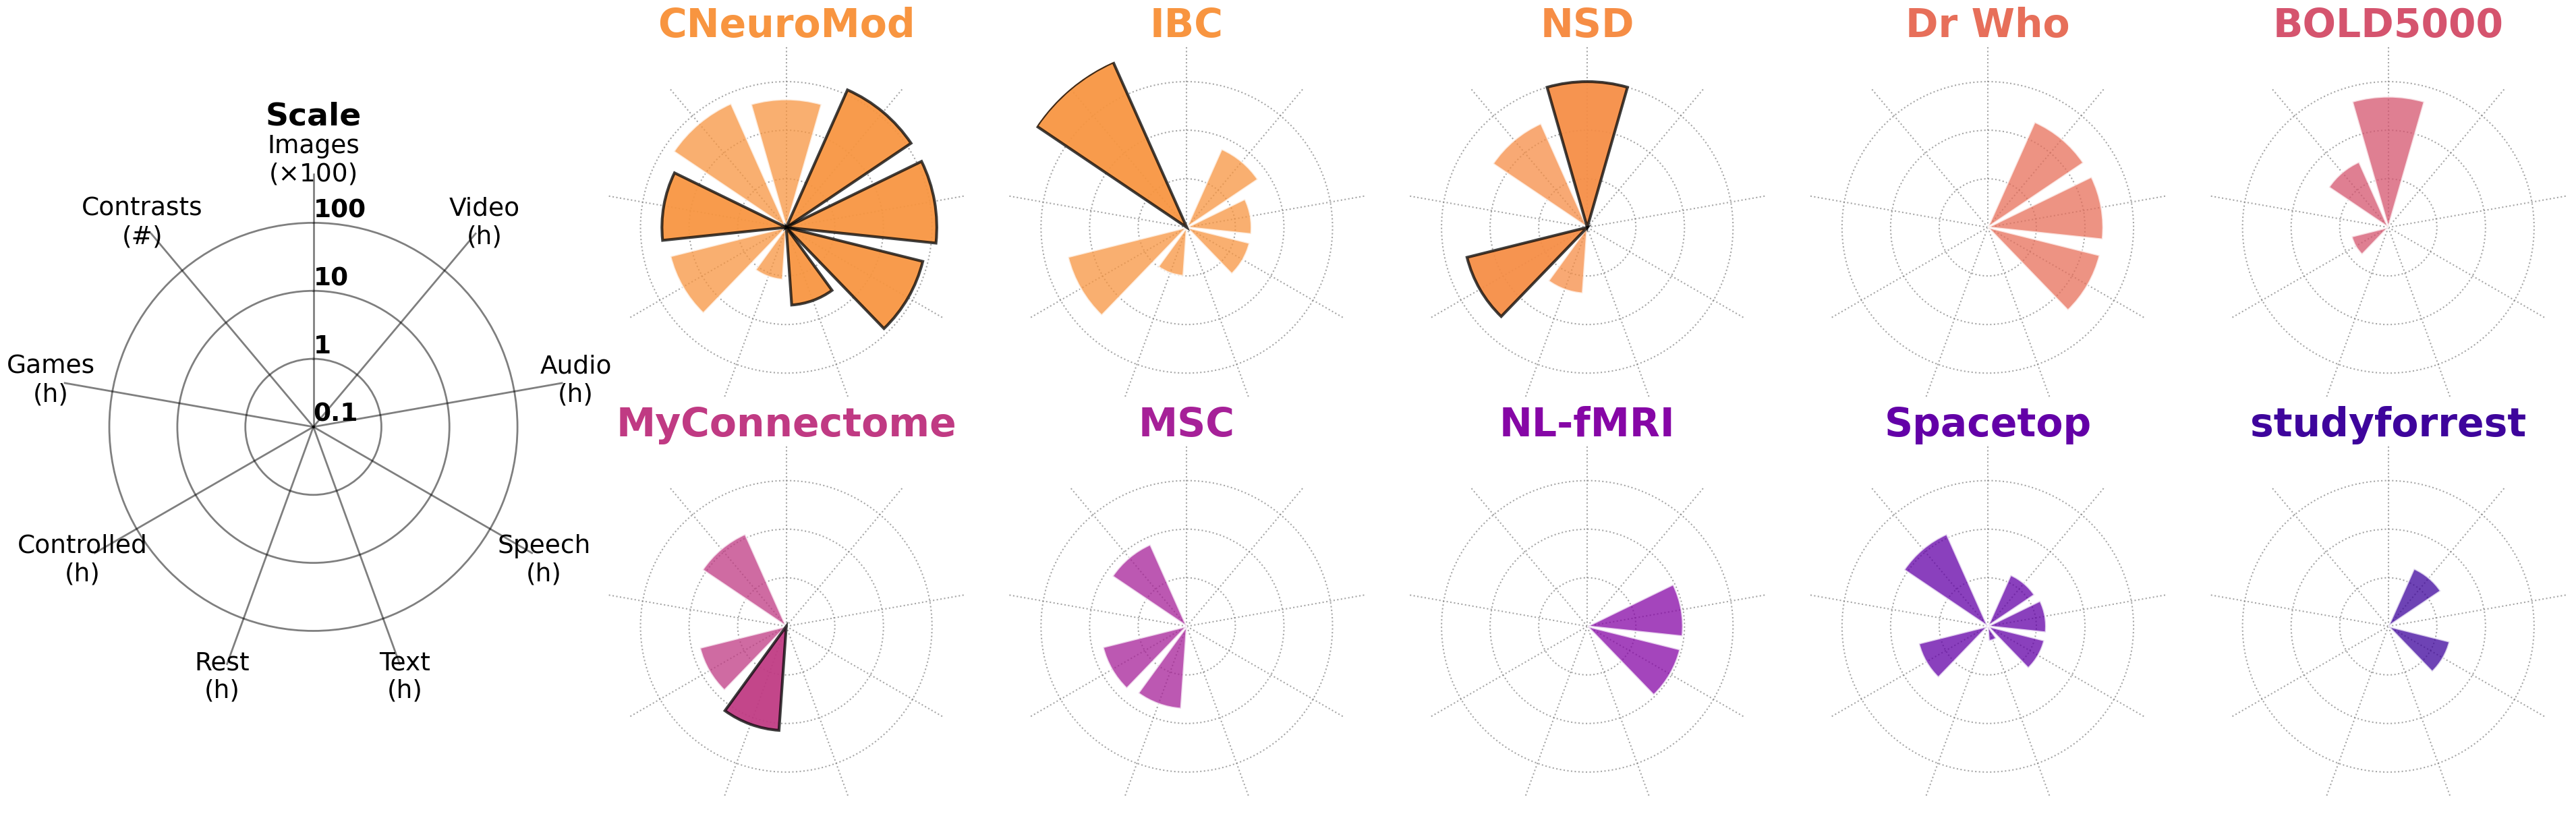

Saved dataset_task_composition_radar_grid.png


In [10]:
make_radar_grid(
    pivot_per_subject,
    datasets_top10_ranked,
    output_dir / "dataset_task_composition_radar_grid.png",
)